In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
m = 50
n = 32

In [8]:
def fjk(j, k):
    return (k+1) / np.sqrt(m) * np.exp(2 * np.pi * 1j * j * k / m)
v = np.arange(1, n + 1)

In [9]:
T = np.fromfunction(fjk, (32, 50))
S = T @ T.conjugate().T

In [28]:
def get_bounds(T):
    svdvals = np.linalg.svdvals(T)
    return svdvals[-1] ** 2, svdvals[0] ** 2

In [6]:
def get_decomposition(T, f):
    return np.linalg.pinv(T) @ f

## Frame bounds

In [29]:
bounds = get_bounds(T)
A, B = bounds
print("Frame bounds:")
bounds

Frame bounds:


(np.float64(7.375000124181121), np.float64(2392.9956154058996))

## Frame decomposition

In [8]:
decomp = get_decomposition(T, v)
print("Exact frame decomposition:")
decomp

Exact frame decomposition:


array([ 2.05036512-1.18636257e+00j, -7.33464896-5.09242198e+00j,
       -1.25297325+8.55823414e+00j, -1.19483066-5.20429149e-01j,
        2.14815314+3.13263115e+00j, -1.56211634+1.42688580e+00j,
        1.48312228+9.83215930e-02j,  0.12472113+2.32344046e+00j,
       -0.47315812-9.51546115e-02j,  1.25909009+9.53012994e-01j,
       -0.63778451+1.28403769e+00j,  0.26286426-2.25290041e-01j,
        0.58146049+1.29751214e+00j, -0.73673048+4.87937818e-01j,
        0.58888321+8.82539423e-02j, -0.07667629+1.23882642e+00j,
       -0.51571216+4.99299173e-03j,  0.56813097+4.87505941e-01j,
       -0.55214617+9.22614329e-01j, -0.19147146-1.77775738e-01j,
        0.29704456+7.91211218e-01j, -0.78943155+4.88551355e-01j,
        0.08723726-1.18730467e-01j, -0.11178569+9.06931762e-01j,
       -0.79655688+5.81999827e-02j,  0.2256866 +9.32210723e-02j,
       -0.54455647+8.04930802e-01j, -0.62509355-2.76690352e-01j,
        0.18011688+3.53990262e-01j, -0.90134663+5.03037736e-01j,
       -0.35200802-4.6333

## Frame algorithm

In [105]:
residual = np.inf
fn = np.zeros_like(v, dtype=np.complex128)
c = T.conjugate().T @ v
n = 1
Sf = T @ c
residuals = []
while np.abs(residual) > 1e-5:
    fn += 2 / (A + B) * (Sf - S @ fn)
    residual = np.power((B - A) / (B + A), n) * np.linalg.norm(fn)
    true_residual = np.linalg.norm(fn - v)
    residuals.append(residual)
    n += 1

In [106]:
print("Reconstructed v:")
fn

Reconstructed v:


array([ 1.00000003+2.37188488e-09j,  2.0000002 +7.56418864e-08j,
        3.00000036+1.79778279e-07j,  4.0000005 +2.92034708e-07j,
        5.0000006 +3.98885146e-07j,  6.00000065+4.91270570e-07j,
        7.00000066+5.63083140e-07j,  8.00000062+6.10554996e-07j,
        9.00000054+6.31931230e-07j, 10.00000041+6.27219644e-07j,
       11.00000024+5.97941880e-07j, 12.00000005+5.46862266e-07j,
       12.99999984+4.77693532e-07j, 13.99999962+3.94789274e-07j,
       14.99999941+3.02838152e-07j, 15.99999921+2.06575542e-07j,
       16.99999904+1.10527814e-07j, 17.99999891+1.88013811e-08j,
       18.99999882-6.50748059e-08j, 19.99999878-1.38249210e-07j,
       20.99999879-1.98590044e-07j, 21.99999885-2.44674661e-07j,
       22.99999896-2.75734252e-07j, 23.99999911-2.91565317e-07j,
       24.99999929-2.92421996e-07j, 25.99999949-2.78906457e-07j,
       26.99999969-2.51878864e-07j, 27.99999989-2.12419902e-07j,
       29.00000006-1.61913647e-07j, 30.00000019-1.02434177e-07j,
       31.00000026-3.8084

## Conjugate Gradient acceleration for the Frame algorithm

In [162]:
def ip(a, b):
    return np.vdot(b, a)

In [166]:
# naive version from the paper
c = T.conjugate().T @ v
r = T @ c
p = r.copy()
Sp = S @ p
x = np.zeros_like(p)
λ = ip(r, p) / ip(p, Sp)
x += λ * p
errors_cg = []
norm = np.linalg.norm(x - v)
errors_cg.append(norm)
r -= λ * Sp
p_new = Sp - (ip(Sp, Sp) / ip(p, Sp)) * p
p_old = p
Spold = Sp
p = p_new
num_iter = 3600
for it in range(num_iter):
    norm = np.linalg.norm(x - v)
    errors_cg.append(norm)

    if norm < 1e-5:
        break
    Sp = S @ p
    λ = ip(r, p) / ip(p, Sp)
    x += λ * p
    r -= λ * Sp

    p_new = Sp - (ip(Sp, Sp) / ip(p, Sp)) * p - (ip(Sp, Spold) / ip(p_old, Spold)) * p_old
    p_old = p
    Spold = Sp
    p = p_new



In [150]:
print("Reconstructed v:")
x

Reconstructed v:


array([ 1.00000014-2.40555081e-08j,  2.00000015+1.46114182e-07j,
        3.00000019+3.80739529e-07j,  4.00000027+5.45823596e-07j,
        5.00000022+6.57377192e-07j,  6.00000001+9.04467575e-07j,
        6.99999977+1.30452673e-06j,  7.99999945+1.53492268e-06j,
        8.99999867+1.47731223e-06j,  9.9999977 +1.28909854e-06j,
       10.99999724+4.08720823e-07j, 11.99999686-1.24359149e-06j,
       12.99999856-1.90244724e-06j, 13.99999896-1.57239206e-06j,
       14.99999966-1.47132553e-06j, 15.99999974-5.02614363e-07j,
       16.99999871-4.24401099e-07j, 17.9999985 -1.37253568e-06j,
       18.99999871-1.76928846e-06j, 19.999999  -3.04724568e-06j,
       21.00000106-2.92883615e-06j, 22.00000153-2.05651365e-06j,
       23.00000181-9.38781136e-07j, 24.00000165-3.89382641e-07j,
       25.00000115-2.66491938e-08j, 26.00000084+2.59893485e-07j,
       27.00000071+2.94898683e-07j, 28.00000052+2.11974629e-07j,
       29.0000003 +2.18511893e-07j, 30.00000018+2.87742408e-07j,
       31.00000015+2.7303

In [158]:
# reformulated two-term p_n version from the paper
c = T.conjugate().T @ v
r = T @ c
p = r.copy()
Sp = S @ p
x = np.zeros_like(p)
errors_cg_two = []
num_iter = 300

for it in range(num_iter):
    norm = np.linalg.norm(x - v)
    errors_cg_two.append(norm)

    if norm < 1e-5:
        break
    Sp = S @ p
    λ = ip(r, p) / ip(p, Sp)
    x += λ * p
    r -= λ * Sp

    p_new = r - (ip(r, Sp) / ip(p, Sp)) * p
    p = p_new

In [159]:
print("Reconstructed v:")
x

Reconstructed v:


array([ 0.99999999-1.65110556e-08j,  1.99999997-5.97904203e-09j,
        2.99999997+1.31035162e-08j,  3.99999999+2.58697695e-08j,
        5.00000001+2.36566026e-08j,  6.00000002+9.43822255e-09j,
        7.00000001-6.10987883e-09j,  8.        -1.31663745e-08j,
        8.99999999-8.19057808e-09j,  9.99999998+5.56068989e-09j,
       10.99999999+1.99169373e-08j, 12.        +2.54558576e-08j,
       13.00000002+1.70336382e-08j, 14.00000003-1.94577379e-09j,
       15.00000002-2.04158164e-08j, 15.99999999-2.59196168e-08j,
       16.99999997-1.26623738e-08j, 17.99999997+1.35247280e-08j,
       18.99999998+3.69125649e-08j, 20.00000002+4.08514999e-08j,
       21.00000004+1.97957213e-08j, 22.00000004-1.43114546e-08j,
       23.00000002-3.84865460e-08j, 23.99999998-3.53705033e-08j,
       24.99999996-7.13182090e-09j, 25.99999997+2.59318159e-08j,
       27.        +4.14675868e-08j, 28.00000003+3.14898532e-08j,
       29.00000004+5.50905792e-09j, 30.00000003-1.92549831e-08j,
       31.00000001-2.9570

In [160]:
# classic version of CG for linear equations
r = T @ c
p = r.copy()
x = np.zeros_like(v, dtype=np.complex128)
errors_cg_classic = []
num_iter = 6800

for it in range(num_iter):
    norm = np.linalg.norm(x - v)
    errors_cg_classic.append(norm)

    if norm < 1e-5:
        break
    Sp = S @ p
    alpha = ip(r, r) / ip(p, Sp)

    x_new = x + alpha * p
    r_new = r - alpha * Sp


    beta = ip(r_new, r_new) / ip(r, r)

    p = r_new + beta * p
    x = x_new
    r = r_new


In [161]:
print("Reconstructed v:")
x

Reconstructed v:


array([ 1.00000001-4.96703036e-09j,  2.        -1.20039136e-08j,
        2.99999999-1.23571710e-08j,  3.99999999-5.55496933e-09j,
        4.99999999+3.39675416e-09j,  6.        +8.13366672e-09j,
        7.        +5.85164414e-09j,  8.00000001-6.48968978e-10j,
        9.        -5.74867963e-09j, 10.        -6.08752713e-09j,
       10.99999999-2.93854788e-09j, 12.        +1.00625877e-10j,
       13.        +1.18756820e-09j, 14.        +1.69170433e-09j,
       15.        +3.46995201e-09j, 16.        +5.21519161e-09j,
       17.        +3.28082018e-09j, 18.00000001-2.97980753e-09j,
       19.        -8.57463432e-09j, 19.99999999-7.41548834e-09j,
       20.99999999+9.96134951e-10j, 21.99999999+1.03642783e-08j,
       23.        +1.30343151e-08j, 24.00000001+6.62390266e-09j,
       25.00000001-4.03310199e-09j, 26.        -1.07917200e-08j,
       26.99999999-8.39334289e-09j, 27.99999999+1.65852282e-09j,
       28.99999999+1.21431035e-08j, 30.        +1.54893264e-08j,
       31.00000001+9.7005

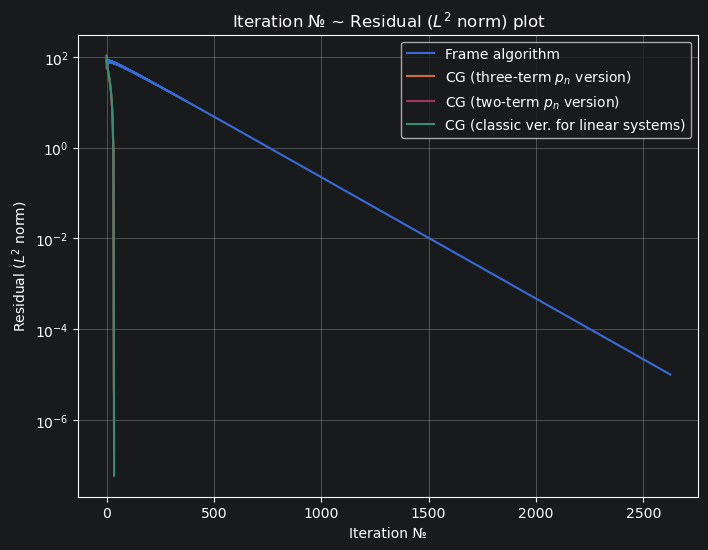

In [168]:
plt.figure(figsize=(8,6))
plt.xlabel("Iteration №")
plt.ylabel("Residual ($L^2$ norm)")
plt.grid(True)
plt.semilogy(residuals, label='Frame algorithm')
plt.semilogy(errors_cg, label='CG (three-term $p_n$ version)')
plt.semilogy(errors_cg_two, label='CG (two-term $p_n$ version)')
plt.semilogy(errors_cg_classic, label='CG (classic ver. for linear systems)')
plt.title("Iteration № ~ Residual ($L^2$ norm) plot")
plt.legend()
plt.show()

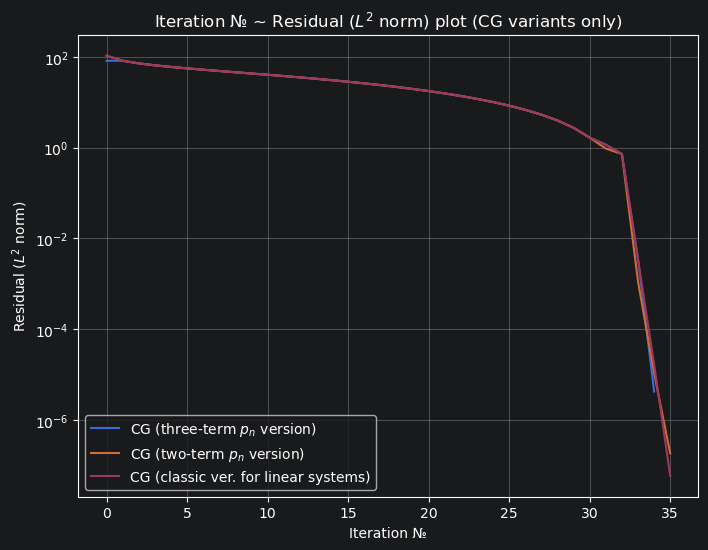

In [167]:
plt.figure(figsize=(8,6))
plt.xlabel("Iteration №")
plt.ylabel("Residual ($L^2$ norm)")
plt.grid(True)
plt.semilogy(errors_cg, label='CG (three-term $p_n$ version)')
plt.semilogy(errors_cg_two, label='CG (two-term $p_n$ version)')
plt.semilogy(errors_cg_classic, label='CG (classic ver. for linear systems)')
plt.title("Iteration № ~ Residual ($L^2$ norm) plot (CG variants only)")
plt.legend()
plt.show()